In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# Set paths (change as per your folder structure)
train_dir = r"C:\Users\Aanchal Gupta\Desktop\Knee X-ray Images\processed_data_70_20_10\train"
val_dir = r"C:\Users\Aanchal Gupta\Desktop\Knee X-ray Images\processed_data_70_20_10\val"
test_dir = r"C:\Users\Aanchal Gupta\Desktop\Knee X-ray Images\processed_data_70_20_10\test"
batch_size = 32
img_size = (224, 224)
num_classes = 5
class_names = ['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']  # Update as per your labels

In [3]:
# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(train_dir, image_size=img_size, batch_size=batch_size)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(val_dir, image_size=img_size, batch_size=batch_size)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(test_dir, image_size=img_size, batch_size=batch_size, shuffle=False)


Found 1149 files belonging to 5 classes.
Found 333 files belonging to 5 classes.
Found 168 files belonging to 5 classes.


In [4]:
# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [5]:
# Build Model
base_model = MobileNetV3Large(input_shape=img_size + (3,), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [6]:
# Callbacks
log_dir = "training_logs"
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
#earlystop_cb = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)


In [7]:
# Train
history = model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=[tensorboard_cb])


Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 609ms/step - accuracy: 0.3875 - loss: 1.5866 - val_accuracy: 0.6156 - val_loss: 1.0398
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 534ms/step - accuracy: 0.6152 - loss: 0.9957 - val_accuracy: 0.6547 - val_loss: 0.8918
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 537ms/step - accuracy: 0.6612 - loss: 0.8541 - val_accuracy: 0.6877 - val_loss: 0.8492
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 534ms/step - accuracy: 0.6846 - loss: 0.7778 - val_accuracy: 0.6877 - val_loss: 0.7660
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 534ms/step - accuracy: 0.7136 - loss: 0.6869 - val_accuracy: 0.6967 - val_loss: 0.7604
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 534ms/step - accuracy: 0.7440 - loss: 0.6587 - val_accuracy: 0.7177 - val_loss: 0.6983
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 535ms/step - accuracy: 0.7595 - loss: 0.6070 - val_accuracy: 0.7147 - val_loss: 0.7150
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 535ms/step - accuracy: 0.7673 - loss: 0.6018 - val_accu

In [21]:
model.get_layer(index=0).summary()


Model: "MobileNetV3Large"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv (Conv2D)                 │ (None, 112, 112, 16)      │             432 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_bn (BatchNormalization)  │ (None, 112, 112, 16)      │              64 │ conv[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 112, 112, 16)      │               0 │ conv_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 16)      │             144 │ activation[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_bn    │ (None, 112, 112, 16)      │              64 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu (ReLU)                  │ (None, 112, 112, 16)      │               0 │ expanded_conv_depthwise_b… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             256 │ re_lu[0][0]                │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_bn      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_add (Add)       │ (None, 112, 112, 16)      │               0 │ activation[0][0],          │
│                               │                           │                 │ expanded_conv_project_bn[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_1_expand        │ (None, 112, 112, 64)      │           1,024 │ expanded_conv_add[0][0]    │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_1_expand_bn     │ (None, 112, 112, 64)      │             256 │ expanded_conv_1_expand[0]… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_1 (ReLU)                │ (None, 112, 112, 64)      │               

 Total params: 2,996,352 (11.43 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,996,352 (11.43 MB)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)        │ (None, 7, 7, 960)           │       2,996,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 960)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 960)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         246,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,738,257 (14.26 MB)

 Trainable params: 247,301 (966.02 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

 Optimizer params: 494,604 (1.89 MB)

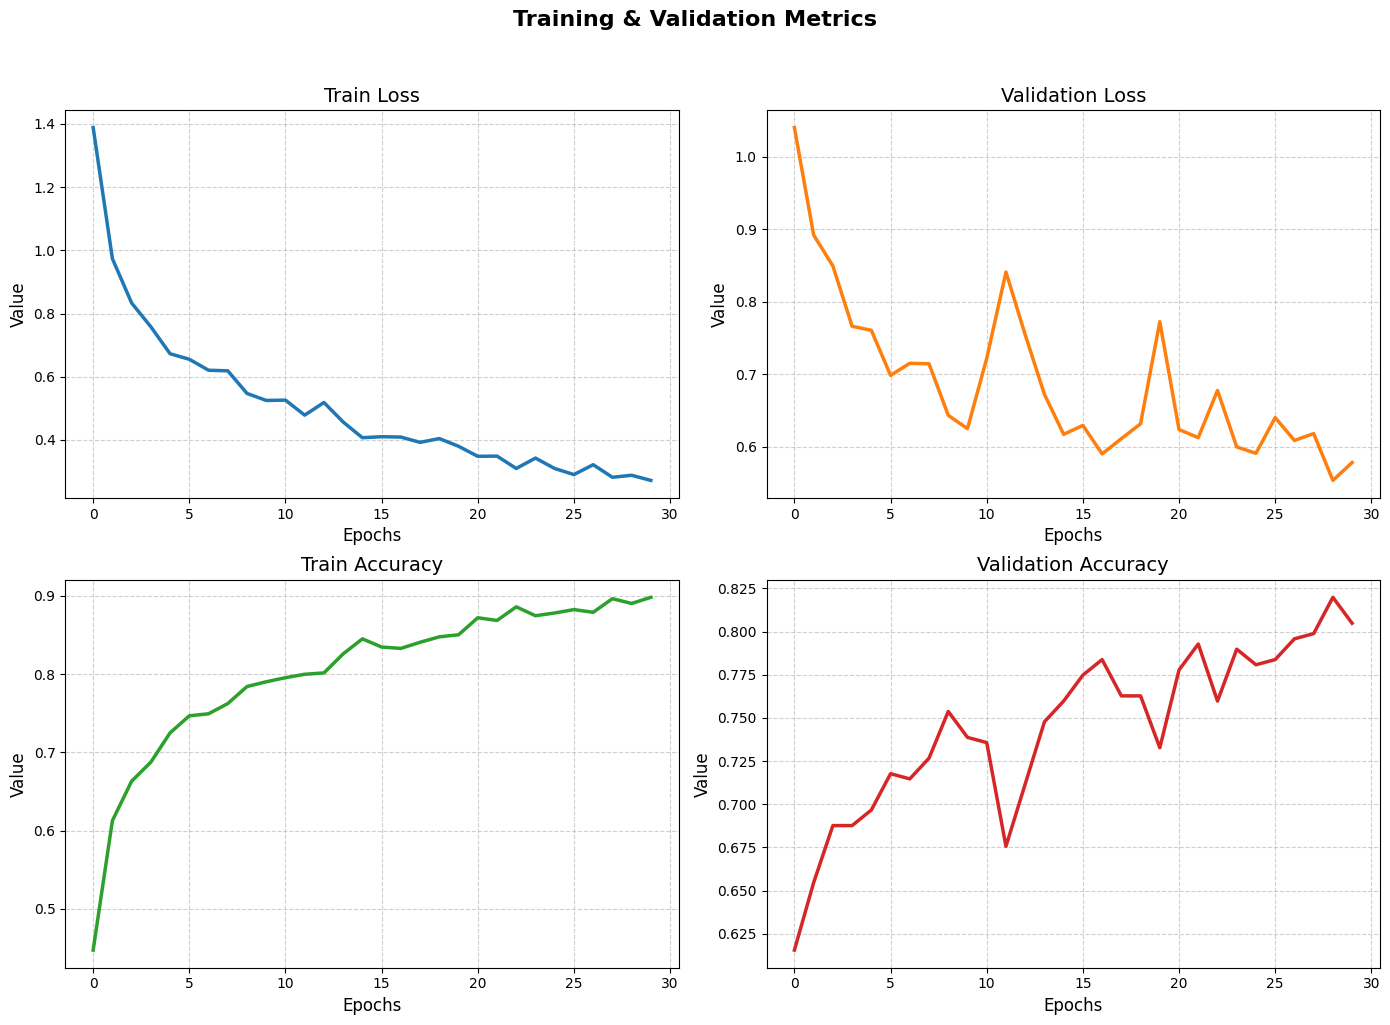

In [9]:
import matplotlib.pyplot as plt

def plot_history(history):
    metrics = {
        'Train Loss': history.history['loss'],
        'Validation Loss': history.history['val_loss'],
        'Train Accuracy': history.history['accuracy'],
        'Validation Accuracy': history.history['val_accuracy']
    }

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
   
    
    plt.figure(figsize=(14, 10))
    
    for i, (title, data) in enumerate(metrics.items(), 1):
        plt.subplot(2, 2, i)
        plt.plot(data, color=colors[i-1], linewidth=2.5)
        plt.title(title, fontsize=14)
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Value', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
    
    plt.suptitle("Training & Validation Metrics", fontsize=16, fontweight='bold', y=1.02)
    plt.subplots_adjust(top=0.92)
    plt.show()

# Call the function with your model history
plot_history(history)

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 919ms/step
              precision    recall  f1-score   support

     0Normal       0.84      0.92      0.88        52
   1Doubtful       0.78      0.73      0.75        48
       2Mild       0.65      0.54      0.59        24
   3Moderate       0.84      0.91      0.88        23
     4Severe       0.81      0.81      0.81        21

    accuracy                           0.80       168
   macro avg       0.78      0.78      0.78       168
weighted avg       0.79      0.80      0.79       168

AUROC for 0Normal: 0.9738
AUROC for 1Doubtful: 0.9250
AUROC for 2Mild: 0.9317
AUROC for 3Moderate: 0.9910
AUROC for 4Severe: 0.9819


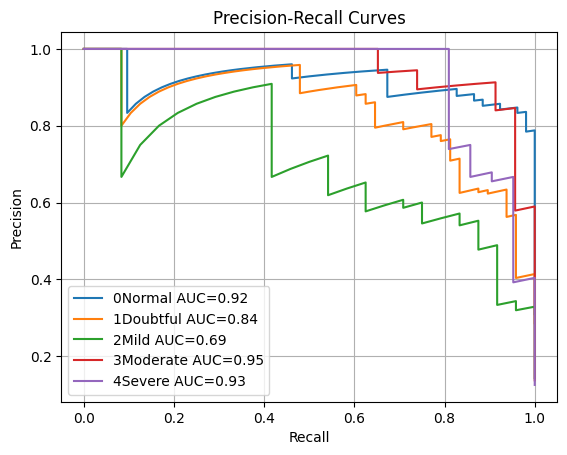

In [8]:
# Predict
y_true = np.concatenate([y.numpy() for x, y in test_ds])
y_probs = model.predict(test_ds)
y_pred = np.argmax(y_probs, axis=1)

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# AUROC per class
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=num_classes)
auroc = roc_auc_score(y_true_onehot, y_probs, average=None)
for idx, auc_val in enumerate(auroc):
    print(f"AUROC for {class_names[idx]}: {auc_val:.4f}")

# AUPRC per class
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_onehot[:, i], y_probs[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{class_names[i]} AUC={pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 358ms/step


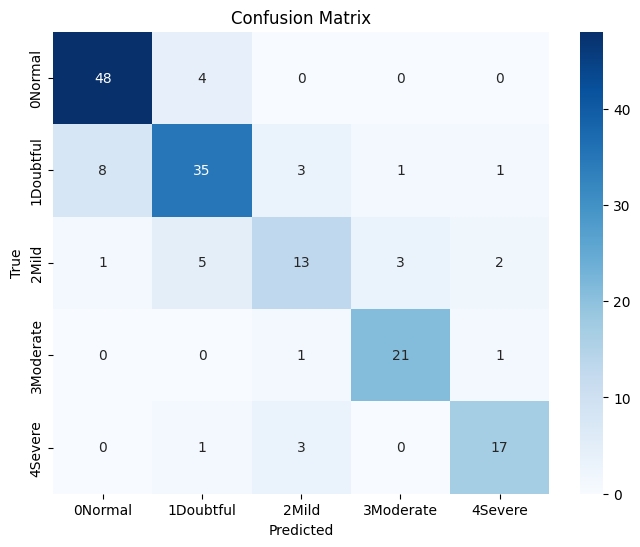

Classification Report:
              precision    recall  f1-score   support

     0Normal       0.84      0.92      0.88        52
   1Doubtful       0.78      0.73      0.75        48
       2Mild       0.65      0.54      0.59        24
   3Moderate       0.84      0.91      0.88        23
     4Severe       0.81      0.81      0.81        21

    accuracy                           0.80       168
   macro avg       0.78      0.78      0.78       168
weighted avg       0.79      0.80      0.79       168

Specificity for class 0Normal: 0.9224
Specificity for class 1Doubtful: 0.9167
Specificity for class 2Mild: 0.9514
Specificity for class 3Moderate: 0.9724
Specificity for class 4Severe: 0.9728
AUROC for class 0Normal: 0.9738
AUROC for class 1Doubtful: 0.9250
AUROC for class 2Mild: 0.9317
AUROC for class 3Moderate: 0.9910
AUROC for class 4Severe: 0.9819

AUPRC (Area under Precision-Recall Curve):
AUPRC for class 0Normal: 0.9154
AUPRC for class 1Doubtful: 0.8359
AUPRC for class 2Mild: 0

In [11]:
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

# 1. True and predicted labels
y_true = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 3. Classification Report: Accuracy, Precision, Recall, F1
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Specificity Calculation
specificity = []
for i in range(num_classes):
    tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    fp = cm[:, i].sum() - cm[i, i]
    specificity_i = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificity.append(specificity_i)

for i, s in enumerate(specificity):
    print(f"Specificity for class {class_names[i]}: {s:.4f}")

# 5. AUROC (One-vs-Rest)
y_true_bin = label_binarize(y_true, classes=range(num_classes))
try:
    aucs = roc_auc_score(y_true_bin, y_pred_probs, average=None)
    for i, auc_val in enumerate(aucs):
        print(f"AUROC for class {class_names[i]}: {auc_val:.4f}")
except ValueError:
    print("Not enough samples per class to calculate AUROC.")

# 6. AUPRC (One-vs-Rest)
print("\nAUPRC (Area under Precision-Recall Curve):")
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred_probs[:, i])
    auprc = auc(recall, precision)
    print(f"AUPRC for class {class_names[i]}: {auprc:.4f}")
